# Modelling: LSTM

This notebook reproduces the exact train/validation/test split from `04_modelling_classical.ipynb` and trains an LSTM on the cleaned `text` column only. Whether this model or the classical model is ultimately deployed is decided in `06_evaluation.ipynb` from held-out test-set performance.

No metadata columns, no test-set evaluation, and no saved model artifact happen in this notebook. The test set stays untouched until `06_evaluation.ipynb`, which is also where the winning pipeline gets persisted.

In [ ]:
# Standard library
import random
import sys

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Show every column when previewing a DataFrame, instead of truncating with "..."
pd.set_option("display.max_columns", None)

# Use a seaborn whitegrid background for every chart in this notebook
sns.set_theme(style="whitegrid")

# Make the repository root importable so src/ can be reached from notebooks/
sys.path.append("..")

# A fixed seed reused from 04_modelling_classical.ipynb so this notebook reproduces the exact same train/validation/test split.
# Every source of randomness this notebook touches (numpy, TensorFlow, and Python's own `random`) is seeded from it.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# By default, TensorFlow can compute some operations (for example on multiple CPU threads via oneDNN) in an order that varies slightly from run to run,
# which can change results even with a fixed seed above. This forces every operation to use a deterministic implementation instead, so re-running this notebook gives the same result each time,
# at some cost to training speed.
tf.config.experimental.enable_op_determinism()

## Load the Cleaned Dataset

The dataset produced by `02_data_preparation.ipynb` is loaded and its shape is checked to confirm it still matches the 17,880 rows and 11 columns already confirmed in `04_modelling_classical.ipynb`.

In [2]:
# Load the cleaned dataset and report its shape
df = pd.read_csv("../data/processed/cleaned.csv")
print(df.shape)

(17880, 11)


## Reproduce the Train/Validation/Test Split

The same two `train_test_split` calls used in `04_modelling_classical.ipynb` are repeated here with the same `RANDOM_STATE`. This produces identical training, validation, and test rows as notebook 04, so the two models are compared on the same data.

Only the `text` column and the `fraudulent` label are used from here on. The LSTM does not see the metadata columns the classical models use.

In [3]:
# Separate the features from the label
X = df.drop(columns=["fraudulent"])
y = df["fraudulent"]

# First split: 70% train, 30% held out for validation and test combined
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Second split: the 30% holdout is split evenly into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.50, stratify=y_holdout, random_state=RANDOM_STATE)

# Report the size and class balance of each split
for name, split_y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    fraud_rate = split_y.mean() * 100
    print(f"{name}: {len(split_y)} rows, {fraud_rate:.2f}% fraudulent")

Train: 12516 rows, 4.84% fraudulent
Validation: 2682 rows, 4.85% fraudulent
Test: 2682 rows, 4.85% fraudulent


## Tokenize and Pad Text

Text needs to become a fixed-length sequence of integers before an LSTM can read it. A `Tokenizer` is fit on the training text only, learning a vocabulary of the 5,000 most frequent words. This is capped to stay comparable to the `max_features` grid used for `TfidfVectorizer` in `04_modelling_classical.ipynb`. It is then only ever used to transform validation and test text, never re-fit, the same leakage guardrail that applies to every other fitted component in this project.

Sequences are padded or truncated to a single fixed length, taken from the median word count of the training postings. The embedding layer below masks the padding positions, so a shorter cap mainly keeps most of a posting's fraud-relevant opening text intact without wasting most of every sequence on padding.

In [4]:
# Build the vocabulary from the training text only, capped at the 5,000 most frequent words to stay comparable to the TF-IDF max_features grid in 04_modelling_classical.ipynb
VOCAB_SIZE = 5000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train["text"])

# Choose a fixed sequence length from the training set's own word-count distribution. The median is used instead of a high percentile as most of a posting's fraud signal sits in its
# opening sentences. A very long cap leaves most sequences dominated by padding which drowns out the real signal even with a masked embedding layer.
train_word_counts = X_train["text"].str.split().str.len()
MAX_LENGTH = int(train_word_counts.median())
print(f"Sequence length capped at {MAX_LENGTH} words (median of training postings)")

# Convert text to integer sequences and pad/truncate every set to the same fixed length. The tokenizer is only ever used to transform validation and test text, never re-fit.
X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train["text"]), maxlen=MAX_LENGTH, padding="post", truncating="post")
X_val_padded = pad_sequences(tokenizer.texts_to_sequences(X_val["text"]), maxlen=MAX_LENGTH, padding="post", truncating="post")
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test["text"]), maxlen=MAX_LENGTH, padding="post", truncating="post")

Sequence length capped at 366 words (median of training postings)


## Build the LSTM Model

The model is a small `Sequential` stack: an `Embedding` layer turns each word index into a dense vector and masks the padding positions (`mask_zero=True`) so the LSTM layer ignores them instead of treating padding as real input, a `Bidirectional` `LSTM` layer reads the sequence of vectors both forwards and backwards and summarises the whole posting into a single vector, a `Dropout` layer randomly drops some of that summary during training to discourage the model from memorising the training set, and a final `Dense` layer with a sigmoid activation turns what is left into a single fraud probability.

Reading the posting in both directions instead of only forwards lets the model use context from later in a posting to interpret words that appeared earlier in it.

Gradients are clipped during optimisation since the large class weight used below to counter the 4.84% fraud rate can otherwise produce unstable, oversized updates early in training.

In [5]:
# Build a small LSTM classifier: an embedding layer turns each word index into a dense vector and masks padding positions, a bidirectional LSTM layer reads the sequence in both directions
# and summarises it into a single vector. Dropout discourages the model from memorising the training set, and the output layer turns what is left into a fraud probability.
model = Sequential([Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True), Bidirectional(LSTM(64)), Dropout(0.3), Dense(1, activation="sigmoid")])

# Clip gradients to guard against the unstable, oversized updates a large class weight can otherwise produce early in training
model.compile(optimizer=tf.keras.optimizers.Adam(clipnorm=1.0), loss="binary_crossentropy", metrics=["accuracy"])
model.build(input_shape=(None, MAX_LENGTH))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 366, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,177 (1.47 MB)

 Trainable params: 386,177 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

## Handle Class Imbalance

Only 4.84% of training postings are fraudulent, the same imbalance that justified `class_weight="balanced"` for both classical models. Keras has no built-in `"balanced"` option, so the same weighting is computed directly with `compute_class_weight` and passed to `model.fit` as `class_weight`, penalising a missed fraudulent posting more heavily than a missed legitimate one.

In [6]:
# Compute a class weight for each label so the LSTM is penalised more for missing the minority fraudulent class, which matches class_weight="balanced" used for both classical models in
# 04_modelling_classical.ipynb
class_weight_values = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weights = dict(enumerate(class_weight_values))
print(class_weights)

{0: np.float64(0.52544080604534), 1: np.float64(10.326732673267326)}


## Train the Model

The model is trained on the padded training sequences, using the padded validation sequences as `validation_data` so validation loss can be tracked every epoch.

Two callbacks manage training. `ReduceLROnPlateau` halves the learning rate once validation loss stalls, letting the model take smaller, more careful steps instead of stopping outright. `EarlyStopping` then stops training once validation loss stops meaningfully improving, restoring the weights from the best epoch instead of the last one.

A `min_delta` and slightly higher `patience` than a single-epoch check keep a single noisy epoch from being mistaken for the model's genuine best.

In [7]:
# Halve the learning rate once validation loss stalls, and stop training once it stops meaningfully improving, restoring the best epoch's weights
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, min_delta=0.001, restore_best_weights=True)

history = model.fit(X_train_padded, y_train, validation_data=(X_val_padded, y_val), epochs=20, batch_size=32, class_weight=class_weights, callbacks=[reduce_lr, early_stopping])

Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step - accuracy: 0.9138 - loss: 0.3959 - val_accuracy: 0.9258 - val_loss: 0.2435 - learning_rate: 0.0010
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9593 - loss: 0.1789 - val_accuracy: 0.9720 - val_loss: 0.1021 - learning_rate: 0.0010
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9788 - loss: 0.0785 - val_accuracy: 0.9855 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9891 - loss: 0.0390 - val_accuracy: 0.9799 - val_loss: 0.0633 - learning_rate: 0.0010
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9947 - loss: 0.0174 - val_accuracy: 0.9851 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9959 - loss: 0.0154 - val_accuracy: 0.9870 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.9975 - l

Training and validation loss are plotted across epochs to check whether the model is overfitting the training set relative to validation.

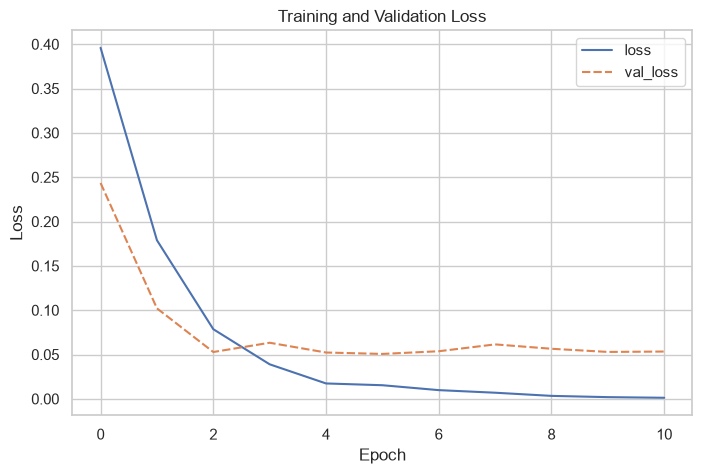

In [8]:
# Plot training and validation loss across epochs to check for overfitting
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=history_df[["loss", "val_loss"]], ax=ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
plt.show()

## Evaluate on the Validation Set

The trained model predicts a fraud probability for every validation posting. Thresholding at 0.5 produces the classification report. The raw probabilities are used for `roc_auc_score` since ROC-AUC only needs postings ranked from least to most likely fraudulent and not calibrated probabilities.

In [9]:
# Predict fraud probabilities on the validation set, then threshold at 0.5 for the classification report
validation_probabilities = model.predict(X_val_padded).ravel()
validation_predictions = (validation_probabilities >= 0.5).astype(int)

print(classification_report(y_val, validation_predictions))
print(f"ROC-AUC: {roc_auc_score(y_val, validation_probabilities):.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.86      0.88      0.87       130

    accuracy                           0.99      2682
   macro avg       0.93      0.93      0.93      2682
weighted avg       0.99      0.99      0.99      2682

ROC-AUC: 0.9803


The confusion matrix is plotted in the same style as `04_modelling_classical.ipynb`'s two classical variants so all three models' false positives and false negatives can be compared side by side in `06_evaluation.ipynb`.

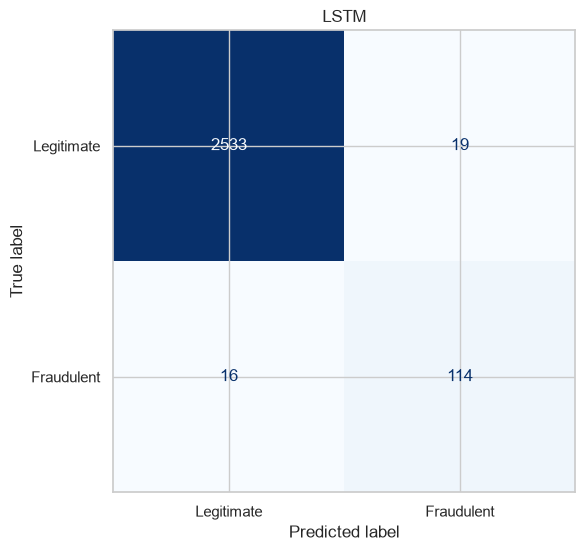

In [10]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_val, validation_predictions, display_labels=["Legitimate", "Fraudulent"], ax=ax, colorbar=False, cmap="Blues")
ax.set_title("LSTM")
plt.show()

## Summary

- Reproduced `04_modelling_classical.ipynb`'s exact split (same `RANDOM_STATE`, same two `train_test_split` calls), confirmed by matching row counts and fraud rates across training, validation, and test sets (12,516 / 2,682 / 2,682 rows; 4.84% / 4.85% / 4.85% fraudulent).
- Tokenized the training text only into a 5,000-word vocabulary and padded every sequence to 366 words, the median length of a training posting. The embedding layer masks the padding so the LSTM only reads real words.
- Trained a small `Embedding` → `Bidirectional LSTM` → `Dropout` → `Dense` model (386,177 parameters) with class weights matching the classical models' `class_weight="balanced"` and clipped gradients. `ReduceLROnPlateau` and `EarlyStopping` managed training, stopping after 11 epochs and restoring the weights from epoch 6, the best validation loss reached.
- On the validation set, the LSTM reaches 0.86 precision, 0.88 recall, and 0.87 F1 on the fraudulent class, with a ROC-AUC of 0.9803. This is a clear improvement over an earlier, single-direction LSTM without masking or a learning-rate schedule, which only reached 0.78 precision, 0.70 recall, 0.74 F1, and 0.9358 ROC-AUC.
- Compared with the classical variants from `04_modelling_classical.ipynb`, the LSTM now has the highest precision and F1 of all three models (Logistic Regression: 0.78 precision, 0.91 recall, 0.84 F1, 0.9944 ROC-AUC; Linear SVM: 0.85 precision, 0.85 recall, 0.85 F1, 0.9927 ROC-AUC), with recall between the two. Its ROC-AUC remains the lowest of the three, though the gap has narrowed considerably. No model is a clean winner across every metric, so `06_evaluation.ipynb` is where the trade-offs are weighed and a final choice is made.
- The test set remains untouched. `06_evaluation.ipynb` brings all three models together, decides which one is deployed based on test-set performance, and saves the winner to `models/deployed_pipeline.joblib`.